## Part ETL Pipline


In [ ]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline


In [ ]:
# Read Datasets -
financial_df = pd.read_csv("/content/financial_dataset.csv")
esg_df = pd.read_csv("/content/esg_dataset.csv")

Data Exploration

In [ ]:
print(financial_df.head())
print(esg_df.head())

   CompanyID CompanyName  Year  Revenue  ProfitMargin  MarketCap  GrowthRate
0          1   Company_1  2015    459.2           6.0      337.5         NaN
1          1   Company_1  2016    473.8           4.6      366.6         3.2
2          1   Company_1  2017    564.9           5.2      313.4        19.2
3          1   Company_1  2018    558.4           4.3      283.0        -1.1
4          1   Company_1  2019    554.5           4.9      538.1        -0.7
   CompanyID CompanyName Industry         Region  Year  ESG_Overall  \
0          1   Company_1   Retail  Latin America  2015         57.0   
1          1   Company_1   Retail  Latin America  2016         56.7   
2          1   Company_1   Retail  Latin America  2017         56.5   
3          1   Company_1   Retail  Latin America  2018         58.0   
4          1   Company_1   Retail  Latin America  2019         56.6   

   ESG_Environmental  ESG_Social  ESG_Governance  CarbonEmissions  WaterUsage  \
0               60.7        33

In [ ]:
print(financial_df.shape)
print(esg_df.shape)

(11000, 7)
(11000, 12)


In [ ]:
print(financial_df.info())
print(esg_df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11000 entries, 0 to 10999
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   CompanyID     11000 non-null  int64  
 1   CompanyName   11000 non-null  object 
 2   Year          11000 non-null  int64  
 3   Revenue       11000 non-null  float64
 4   ProfitMargin  11000 non-null  float64
 5   MarketCap     11000 non-null  float64
 6   GrowthRate    10000 non-null  float64
dtypes: float64(4), int64(2), object(1)
memory usage: 601.7+ KB
None
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11000 entries, 0 to 10999
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CompanyID          11000 non-null  int64  
 1   CompanyName        11000 non-null  object 
 2   Industry           11000 non-null  object 
 3   Region             11000 non-null  object 
 4   Year               11000 non-null 

In [ ]:
print(financial_df.columns)
print(esg_df.columns)

Index(['CompanyID', 'CompanyName', 'Year', 'Revenue', 'ProfitMargin',
       'MarketCap', 'GrowthRate'],
      dtype='object')
Index(['CompanyID', 'CompanyName', 'Industry', 'Region', 'Year', 'ESG_Overall',
       'ESG_Environmental', 'ESG_Social', 'ESG_Governance', 'CarbonEmissions',
       'WaterUsage', 'EnergyConsumption'],
      dtype='object')


In [ ]:
print(financial_df.describe())
print(esg_df.describe())

          CompanyID          Year        Revenue  ProfitMargin      MarketCap  \
count  11000.000000  11000.000000   11000.000000  11000.000000   11000.000000   
mean     500.500000   2020.000000    4670.850591     10.900455   13380.622236   
std      288.688113      3.162421    9969.954369      8.758711   39922.870373   
min        1.000000   2015.000000      35.900000    -20.000000       1.800000   
25%      250.750000   2017.000000     938.775000      5.300000    1098.525000   
50%      500.500000   2020.000000    1902.300000     10.500000    3096.450000   
75%      750.250000   2023.000000    4342.625000     16.300000    9995.500000   
max     1000.000000   2025.000000  180810.400000     50.000000  865271.700000   

         GrowthRate  
count  10000.000000  
mean       4.830370  
std        9.424787  
min      -36.000000  
25%       -1.325000  
50%        4.900000  
75%       11.000000  
max       38.000000  
          CompanyID          Year   ESG_Overall  ESG_Environmental  \
co

Data Cleaning

In [ ]:
print(financial_df.isnull().sum())
print(esg_df.isnull().sum())

CompanyID          0
CompanyName        0
Year               0
Revenue            0
ProfitMargin       0
MarketCap          0
GrowthRate      1000
dtype: int64
CompanyID            0
CompanyName          0
Industry             0
Region               0
Year                 0
ESG_Overall          0
ESG_Environmental    0
ESG_Social           0
ESG_Governance       0
CarbonEmissions      0
WaterUsage           0
EnergyConsumption    0
dtype: int64


In [ ]:
print(financial_df.duplicated().sum())
print(esg_df.duplicated().sum())

0
0


In [ ]:
financial_df.drop_duplicates(inplace=True)
esg_df.drop_duplicates(inplace=True)

In [ ]:
print(financial_df.dtypes)
print(esg_df.dtypes)

CompanyID         int64
CompanyName      object
Year              int64
Revenue         float64
ProfitMargin    float64
MarketCap       float64
GrowthRate      float64
dtype: object
CompanyID              int64
CompanyName           object
Industry              object
Region                object
Year                   int64
ESG_Overall          float64
ESG_Environmental    float64
ESG_Social           float64
ESG_Governance       float64
CarbonEmissions      float64
WaterUsage           float64
EnergyConsumption    float64
dtype: object


In [ ]:
# Merge
merged_df = pd.merge(
    financial_df,
    esg_df,
    on=["CompanyID", "Year"],
    how="inner"
)

In [ ]:
print(merged_df.head())
print(merged_df.shape)
print(merged_df.info())

   CompanyID CompanyName_x  Year  Revenue  ProfitMargin  MarketCap  \
0          1     Company_1  2015    459.2           6.0      337.5   
1          1     Company_1  2016    473.8           4.6      366.6   
2          1     Company_1  2017    564.9           5.2      313.4   
3          1     Company_1  2018    558.4           4.3      283.0   
4          1     Company_1  2019    554.5           4.9      538.1   

   GrowthRate CompanyName_y Industry         Region  ESG_Overall  \
0         NaN     Company_1   Retail  Latin America         57.0   
1         3.2     Company_1   Retail  Latin America         56.7   
2        19.2     Company_1   Retail  Latin America         56.5   
3        -1.1     Company_1   Retail  Latin America         58.0   
4        -0.7     Company_1   Retail  Latin America         56.6   

   ESG_Environmental  ESG_Social  ESG_Governance  CarbonEmissions  WaterUsage  \
0               60.7        33.5            76.8          35577.4     17788.7   
1       

In [ ]:
merged_df.to_csv("unified_dataset.csv", index=False)

print("Unified dataset saved successfully.")

Unified dataset saved successfully.


Data Validation

In [ ]:
print(merged_df.shape)

(11000, 17)


In [ ]:
print(merged_df.describe())

          CompanyID          Year        Revenue  ProfitMargin      MarketCap  \
count  11000.000000  11000.000000   11000.000000  11000.000000   11000.000000   
mean     500.500000   2020.000000    4670.850591     10.900455   13380.622236   
std      288.688113      3.162421    9969.954369      8.758711   39922.870373   
min        1.000000   2015.000000      35.900000    -20.000000       1.800000   
25%      250.750000   2017.000000     938.775000      5.300000    1098.525000   
50%      500.500000   2020.000000    1902.300000     10.500000    3096.450000   
75%      750.250000   2023.000000    4342.625000     16.300000    9995.500000   
max     1000.000000   2025.000000  180810.400000     50.000000  865271.700000   

         GrowthRate   ESG_Overall  ESG_Environmental    ESG_Social  \
count  10000.000000  11000.000000       11000.000000  11000.000000   
mean       4.830370     54.615273          56.416991     55.660582   
std        9.424787     15.893937          26.767233     23.

In [ ]:
print(merged_df.isnull().sum())

CompanyID               0
CompanyName_x           0
Year                    0
Revenue                 0
ProfitMargin            0
MarketCap               0
GrowthRate           1000
CompanyName_y           0
Industry                0
Region                  0
ESG_Overall             0
ESG_Environmental       0
ESG_Social              0
ESG_Governance          0
CarbonEmissions         0
WaterUsage              0
EnergyConsumption       0
dtype: int64


In [ ]:
print(merged_df.duplicated().sum())

0


In [ ]:
merged_df.drop_duplicates(inplace=True)

In [ ]:
print(merged_df.dtypes)

CompanyID              int64
CompanyName_x         object
Year                   int64
Revenue              float64
ProfitMargin         float64
MarketCap            float64
GrowthRate           float64
CompanyName_y         object
Industry              object
Region                object
ESG_Overall          float64
ESG_Environmental    float64
ESG_Social           float64
ESG_Governance       float64
CarbonEmissions      float64
WaterUsage           float64
EnergyConsumption    float64
dtype: object


Exploratory Data Analysis (EDA)

In [ ]:
print(merged_df.head())

   CompanyID CompanyName_x  Year  Revenue  ProfitMargin  MarketCap  \
0          1     Company_1  2015    459.2           6.0      337.5   
1          1     Company_1  2016    473.8           4.6      366.6   
2          1     Company_1  2017    564.9           5.2      313.4   
3          1     Company_1  2018    558.4           4.3      283.0   
4          1     Company_1  2019    554.5           4.9      538.1   

   GrowthRate CompanyName_y Industry         Region  ESG_Overall  \
0         NaN     Company_1   Retail  Latin America         57.0   
1         3.2     Company_1   Retail  Latin America         56.7   
2        19.2     Company_1   Retail  Latin America         56.5   
3        -1.1     Company_1   Retail  Latin America         58.0   
4        -0.7     Company_1   Retail  Latin America         56.6   

   ESG_Environmental  ESG_Social  ESG_Governance  CarbonEmissions  WaterUsage  \
0               60.7        33.5            76.8          35577.4     17788.7   
1       

In [ ]:
print(merged_df.columns)

Index(['CompanyID', 'CompanyName_x', 'Year', 'Revenue', 'ProfitMargin',
       'MarketCap', 'GrowthRate', 'CompanyName_y', 'Industry', 'Region',
       'ESG_Overall', 'ESG_Environmental', 'ESG_Social', 'ESG_Governance',
       'CarbonEmissions', 'WaterUsage', 'EnergyConsumption'],
      dtype='object')


In [ ]:
print(merged_df.corr(numeric_only=True))

                      CompanyID          Year   Revenue  ProfitMargin  \
CompanyID          1.000000e+00 -1.281653e-12 -0.037784      0.034306   
Year              -1.281653e-12  1.000000e+00  0.102280     -0.002463   
Revenue           -3.778439e-02  1.022803e-01  1.000000      0.132488   
ProfitMargin       3.430582e-02 -2.463087e-03  0.132488      1.000000   
MarketCap         -3.856375e-02  8.337931e-02  0.836884      0.259927   
GrowthRate         1.476378e-02 -3.810776e-03  0.165195      0.060733   
ESG_Overall        2.316232e-02  1.278648e-01  0.148869      0.088006   
ESG_Environmental  2.657654e-02  1.089338e-01  0.206628      0.218662   
ESG_Social         2.990646e-03  7.083805e-02  0.047173     -0.032642   
ESG_Governance     1.272484e-02  6.035195e-02  0.018489     -0.035372   
CarbonEmissions    1.225854e-02  4.549357e-02  0.507967     -0.006027   
WaterUsage         1.031023e-02  6.033245e-02  0.540424     -0.002967   
EnergyConsumption  1.468242e-02  4.076111e-02  0.47

In [ ]:
# Feature Engineering 1
def sustainability(score):
    if score >= 80:
        return "High"
    elif score >= 60:
        return "Medium"
    else:
        return "Low"

In [ ]:
merged_df["Sustainability_Level"] = merged_df["ESG_Overall"].apply(sustainability)

In [ ]:
# Feature Engineering 2
merged_df["Carbon_Efficiency"] = merged_df["Revenue"] / merged_df["CarbonEmissions"]

In [ ]:
# Feature Engineering 3
merged_df["Energy_Efficiency"] = merged_df["Revenue"] / merged_df["EnergyConsumption"]

In [ ]:
# Feature Engineering 4
merged_df["Water_Efficiency"] = merged_df["Revenue"] / merged_df["WaterUsage"]

In [ ]:
# Fill GrowthRate
merged_df["GrowthRate"] = merged_df["GrowthRate"].fillna(0)

In [ ]:
# Delete the duplicate name
merged_df.drop(columns=["CompanyName_y"], inplace=True)
merged_df.rename(columns={
    "CompanyName_x":"CompanyName"
}, inplace=True)

In [ ]:
print(merged_df.isnull().sum())
print(merged_df.columns)
print(merged_df.shape)

CompanyID               0
CompanyName             0
Year                    0
Revenue                 0
ProfitMargin            0
MarketCap               0
GrowthRate              0
Industry                0
Region                  0
ESG_Overall             0
ESG_Environmental       0
ESG_Social              0
ESG_Governance          0
CarbonEmissions         0
WaterUsage              0
EnergyConsumption       0
Sustainability_Level    0
Carbon_Efficiency       0
Energy_Efficiency       0
Water_Efficiency        0
dtype: int64
Index(['CompanyID', 'CompanyName', 'Year', 'Revenue', 'ProfitMargin',
       'MarketCap', 'GrowthRate', 'Industry', 'Region', 'ESG_Overall',
       'ESG_Environmental', 'ESG_Social', 'ESG_Governance', 'CarbonEmissions',
       'WaterUsage', 'EnergyConsumption', 'Sustainability_Level',
       'Carbon_Efficiency', 'Energy_Efficiency', 'Water_Efficiency'],
      dtype='object')
(11000, 20)


In [ ]:
merged_df.to_csv("unified_dataset.csv", index=False)

It categorizes companies based on their ESG rating.

In [ ]:
merged_df.to_csv("unified_dataset.csv", index=False)

In [ ]:
# ==========================================
# ETL / Data Preparation Pipeline
# ==========================================

In [ ]:
# Step 1: Extract
def extract(financial_path, esg_path):
    financial_df = pd.read_csv(financial_path)
    esg_df = pd.read_csv(esg_path)
    print("Datasets loaded successfully.")
    return financial_df, esg_df


# Step 2: Clean
def clean(financial_df, esg_df):

    # Fill missing values
    financial_df["GrowthRate"] = financial_df["GrowthRate"].fillna(0)

    # Remove duplicates
    financial_df = financial_df.drop_duplicates()
    esg_df = esg_df.drop_duplicates()

    return financial_df, esg_df


# Step 3: Transform
def transform(financial_df, esg_df):

    merged_df = pd.merge(
        financial_df,
        esg_df,
        on=["CompanyID", "Year"],
        how="inner"
    )

    merged_df.drop(columns=["CompanyName_y"], inplace=True)

    merged_df.rename(
        columns={"CompanyName_x": "CompanyName"},
        inplace=True
    )

    return merged_df


# Step 4: Prepare
def prepare(merged_df):

    def sustainability(score):
        if score >= 80:
            return "High"
        elif score >= 60:
            return "Medium"
        else:
            return "Low"

    merged_df["Sustainability_Level"] = merged_df["ESG_Overall"].apply(sustainability)

    merged_df["Carbon_Efficiency"] = (
        merged_df["Revenue"] / merged_df["CarbonEmissions"]
    )

    merged_df["Energy_Efficiency"] = (
        merged_df["Revenue"] / merged_df["EnergyConsumption"]
    )

    merged_df["Water_Efficiency"] = (
        merged_df["Revenue"] / merged_df["WaterUsage"]
    )

    return merged_df


# ETL Pipeline
def pipeline(financial_path, esg_path):

    financial_df, esg_df = extract(financial_path, esg_path)

    financial_df, esg_df = clean(financial_df, esg_df)

    merged_df = transform(financial_df, esg_df)

    merged_df = prepare(merged_df)

    return merged_df

In [ ]:
final_dataset = pipeline(
    "financial_dataset.csv",
    "esg_dataset.csv"
)
print(final_dataset.head())
final_dataset.to_csv("unified_dataset.csv", index=False)
print("Pipeline executed successfully.")

Datasets loaded successfully.
   CompanyID CompanyName  Year  Revenue  ProfitMargin  MarketCap  GrowthRate  \
0          1   Company_1  2015    459.2           6.0      337.5         0.0   
1          1   Company_1  2016    473.8           4.6      366.6         3.2   
2          1   Company_1  2017    564.9           5.2      313.4        19.2   
3          1   Company_1  2018    558.4           4.3      283.0        -1.1   
4          1   Company_1  2019    554.5           4.9      538.1        -0.7   

  Industry         Region  ESG_Overall  ESG_Environmental  ESG_Social  \
0   Retail  Latin America         57.0               60.7        33.5   
1   Retail  Latin America         56.7               58.9        32.8   
2   Retail  Latin America         56.5               57.6        34.0   
3   Retail  Latin America         58.0               62.3        33.4   
4   Retail  Latin America         56.6               63.7        30.0   

   ESG_Governance  CarbonEmissions  WaterUsage  En

## ML Part

In [ ]:
# Features (X)
X = merged_df[
    [
        "Revenue",
        "ProfitMargin",
        "MarketCap",
        "GrowthRate",
        "CarbonEmissions",
        "WaterUsage",
        "EnergyConsumption",
        "Industry",
        "Region"
    ]
]

# Target (y)
y = merged_df["ESG_Overall"]

print("Features Shape:", X.shape)
print("Target Shape:", y.shape)

Features Shape: (11000, 9)
Target Shape: (11000,)


In [ ]:
# Combine X and y
data = pd.concat([X, y], axis=1)

# Remove missing values
data = data.dropna()

# Split again
X = data.drop("ESG_Overall", axis=1)
y = data["ESG_Overall"]

print("Dataset after removing missing values:")
print(X.shape)

Dataset after removing missing values:
(11000, 9)


In [ ]:
# Categorical columns
categorical_features = ["Industry", "Region"]

# Numerical columns
numerical_features = [
    "Revenue",
    "ProfitMargin",
    "MarketCap",
    "GrowthRate",
    "CarbonEmissions",
    "WaterUsage",
    "EnergyConsumption"
]

# One-Hot Encoding
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ],
    remainder="passthrough"
)

print("Preprocessor created successfully!")

Preprocessor created successfully!


In [ ]:
# Split the dataset into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training samples:", X_train.shape)
print("Testing samples:", X_test.shape)

Training samples: (8800, 9)
Testing samples: (2200, 9)


In [ ]:
# Create Random Forest Pipeline

model = Pipeline([
    ("preprocessor", preprocessor),
    ("regressor", RandomForestRegressor(
        n_estimators=100,
        random_state=42
    ))
])

print("Pipeline created successfully!")

Pipeline created successfully!


In [ ]:
# Train the model

model.fit(X_train, y_train)

print("Model trained successfully!")

Model trained successfully!


In [ ]:
# Predict ESG scores

y_pred = model.predict(X_test)

print("Prediction completed!")

Prediction completed!


In [ ]:
# Evaluate the model

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("=" * 40)
print("Random Forest Regressor Results")
print("=" * 40)

print(f"MAE : {mae:.2f}")
print(f"MSE : {mse:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R² Score: {r2:.4f}")

Random Forest Regressor Results
MAE : 5.90
MSE : 62.13
RMSE: 7.88
R² Score: 0.7368


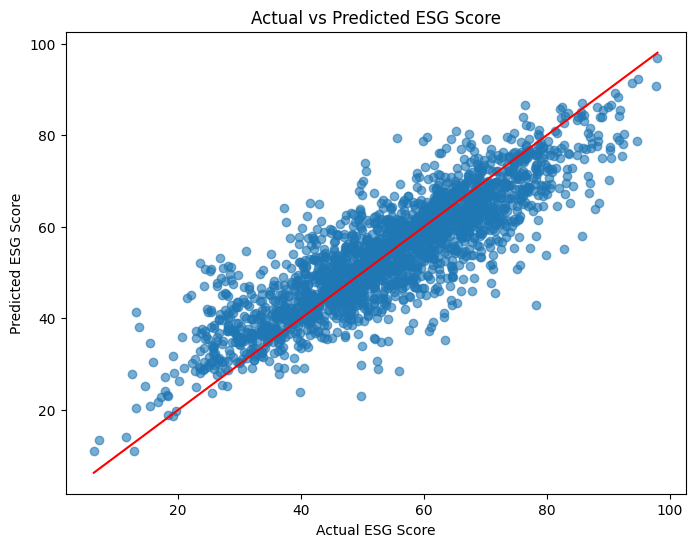

In [ ]:
plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred, alpha=0.6)

plt.xlabel("Actual ESG Score")
plt.ylabel("Predicted ESG Score")
plt.title("Actual vs Predicted ESG Score")

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red"
)

plt.show()

In [ ]:
# Get feature names after encoding

feature_names = model.named_steps["preprocessor"].get_feature_names_out()

importances = model.named_steps["regressor"].feature_importances_

importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
})

importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)

importance_df.head(10)

,Feature,Importance
16,remainder__Revenue,0.140422
11,cat__Region_Europe,0.115300
22,remainder__EnergyConsumption,0.107084
17,remainder__ProfitMargin,0.093900
20,remainder__CarbonEmissions,0.089322
14,cat__Region_North America,0.081660
21,remainder__WaterUsage,0.078872
15,cat__Region_Oceania,0.076279
18,remainder__MarketCap,0.060293
19,remainder__GrowthRate,0.046041


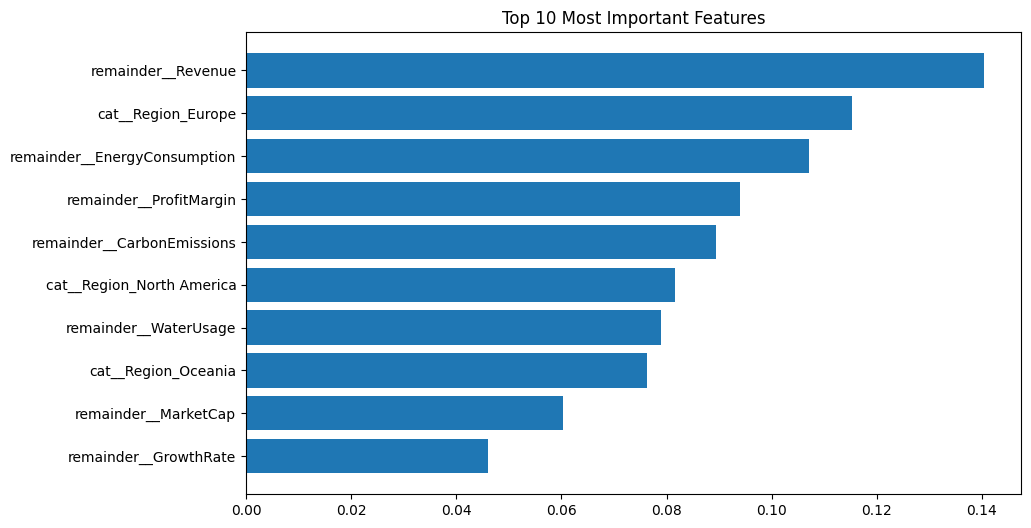

In [ ]:
plt.figure(figsize=(10,6))

plt.barh(
    importance_df["Feature"][:10],
    importance_df["Importance"][:10]
)

plt.gca().invert_yaxis()

plt.title("Top 10 Most Important Features")

plt.show()

In [ ]:
joblib.dump(model, "random_forest_regressor.pkl")

print("Model saved successfully!")

Model saved successfully!


## KPI's & Chart & Insights

In [ ]:
# KPI Calculations
total_revenue = merged_df["Revenue"].sum()
avg_profit_margin = merged_df["ProfitMargin"].mean()
avg_esg_score = merged_df["ESG_Overall"].mean()
total_carbon = merged_df["CarbonEmissions"].sum()
avg_growth = merged_df["GrowthRate"].mean()
high_esg_companies = merged_df[merged_df["Sustainability_Level"] == "High"]["CompanyID"].nunique()

kpis = {
    "Total Revenue ($M)": f"{total_revenue:,.2f}",
    "Avg Profit Margin (%)": f"{avg_profit_margin:,.2f}%",
    "Avg ESG Score": f"{avg_esg_score:,.2f}",
    "Avg Growth Rate (%)": f"{avg_growth:,.2f}%",
    "Total Carbon Emissions": f"{total_carbon:,.2f}",
    "High ESG Companies": f"{high_esg_companies}"
}

kpi_df = pd.DataFrame(list(kpis.items()), columns=["KPI", "Value"])
display(kpi_df.style.set_properties(**{'background-color': '#f4f4f4', 'color': '#1a365d', 'border': '1px solid white', 'font-size': '14pt', 'font-weight': 'bold'}))

,KPI,Value
0,Total Revenue ($M),"51,379,356.50"
1,Avg Profit Margin (%),10.90%
2,Avg ESG Score,54.62
3,Avg Growth Rate (%),4.39%
4,Total Carbon Emissions,"13,986,085,812.80"
5,High ESG Companies,86


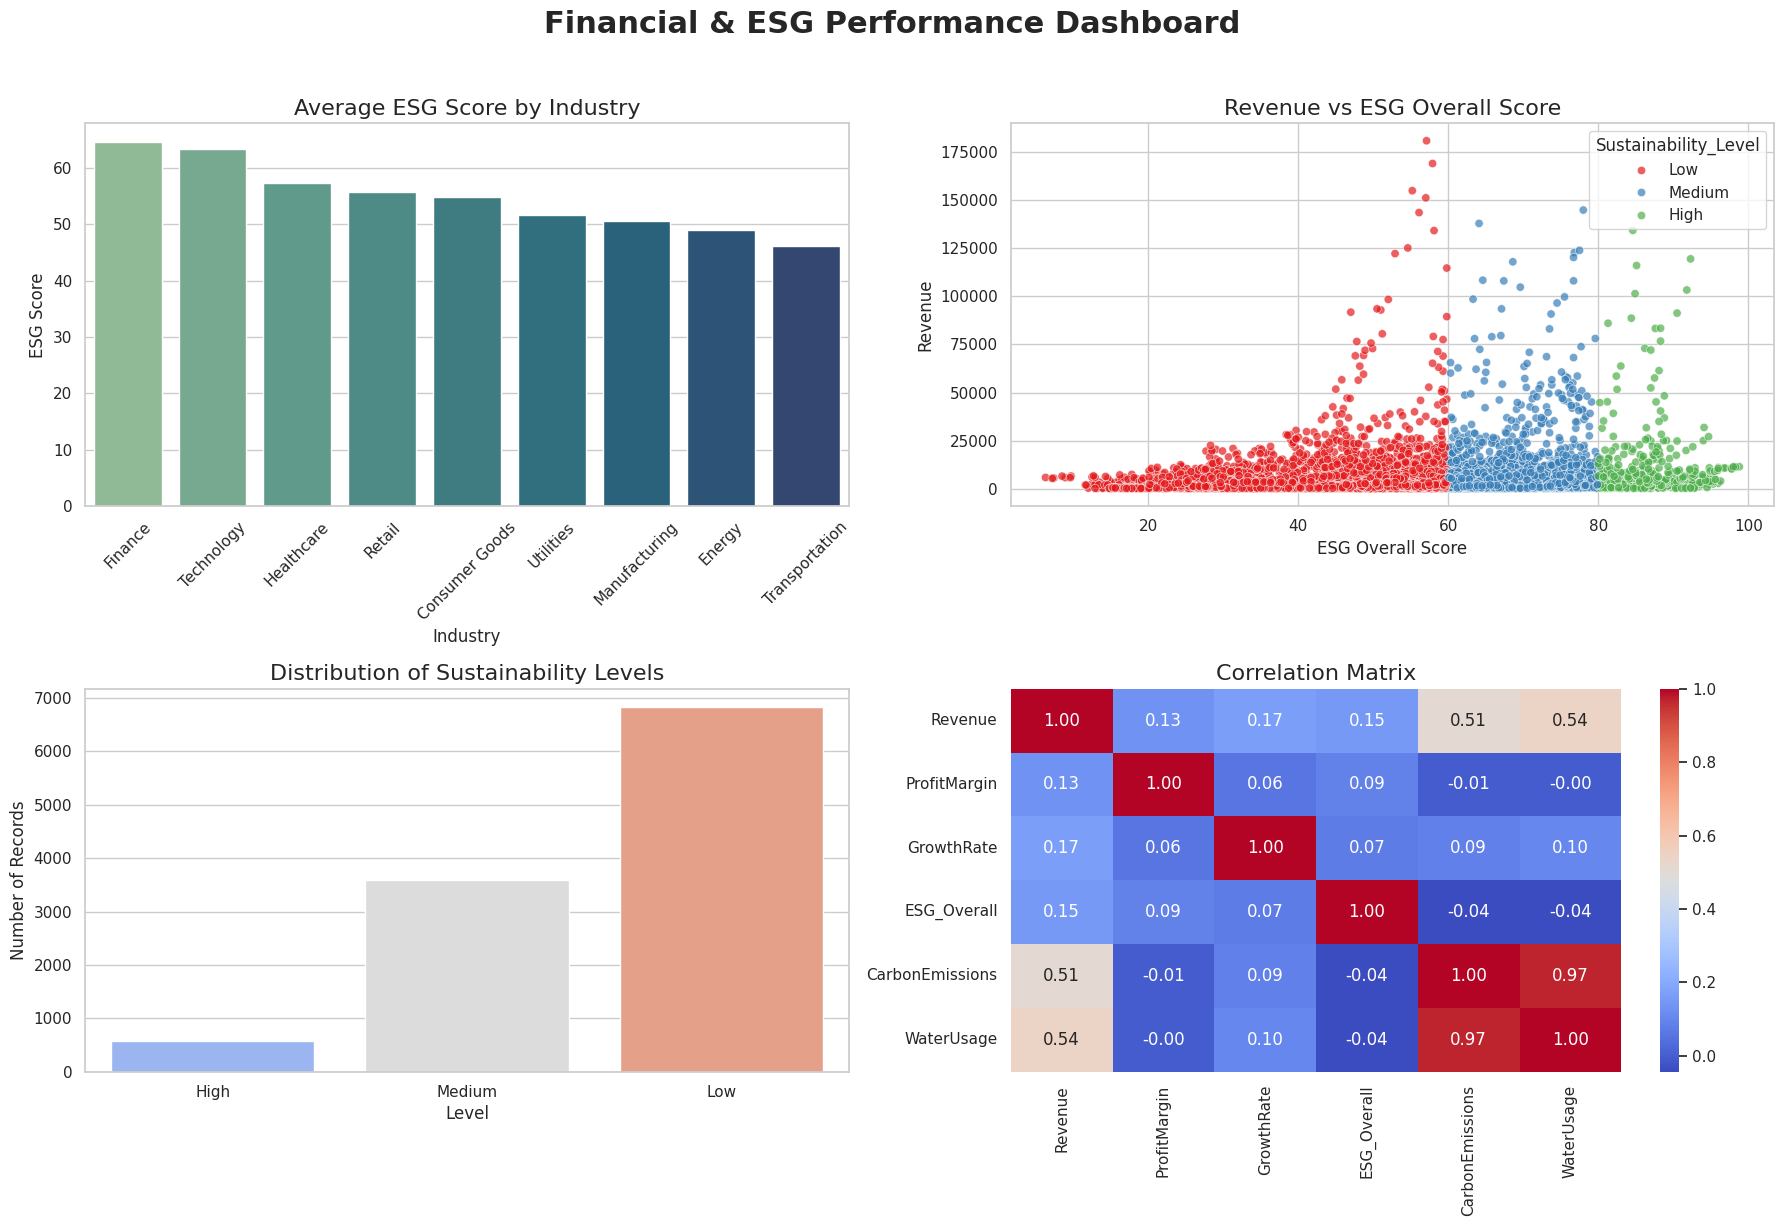

In [58]:
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
fig.suptitle('Financial & ESG Performance Dashboard', fontsize=22, fontweight='bold', y=1.02)

# 1. Average ESG Score by Industry
esg_by_industry = merged_df.groupby("Industry")["ESG_Overall"].mean().sort_values(ascending=False)
sns.barplot(x=esg_by_industry.index, y=esg_by_industry.values, ax=axes[0, 0], palette="crest")
axes[0, 0].set_title("Average ESG Score by Industry", fontsize=16)
axes[0, 0].set_ylabel("ESG Score")
axes[0, 0].tick_params(axis='x', rotation=45)

# 2. Revenue vs ESG Overall Score
sns.scatterplot(data=merged_df, x="ESG_Overall", y="Revenue", hue="Sustainability_Level", alpha=0.7, palette="Set1", ax=axes[0, 1])
axes[0, 1].set_title("Revenue vs ESG Overall Score", fontsize=16)
axes[0, 1].set_xlabel("ESG Overall Score")
axes[0, 1].set_ylabel("Revenue")

# 3. Distribution of Sustainability Levels
sns.countplot(data=merged_df, x="Sustainability_Level", order=["High", "Medium", "Low"], palette="coolwarm", ax=axes[1, 0])
axes[1, 0].set_title("Distribution of Sustainability Levels", fontsize=16)
axes[1, 0].set_xlabel("Level")
axes[1, 0].set_ylabel("Number of Records")

# 4. Correlation Heatmap (Key Metrics)
cols_for_corr = ["Revenue", "ProfitMargin", "GrowthRate", "ESG_Overall", "CarbonEmissions", "WaterUsage"]
sns.heatmap(merged_df[cols_for_corr].corr(), annot=True, cmap="coolwarm", ax=axes[1, 1], fmt=".2f")
axes[1, 1].set_title("Correlation Matrix", fontsize=16)

plt.tight_layout()
plt.show()

In [59]:
# Recommendations Generation based on Logic
merged_df["Recommendation"] = "Monitor Performance"

# Rules
avg_carbon_eff = merged_df["Carbon_Efficiency"].mean()

merged_df.loc[merged_df["Sustainability_Level"] == "Low", "Recommendation"] = "Improve ESG Policies & Initiatives"
merged_df.loc[(merged_df["Carbon_Efficiency"] < avg_carbon_eff) & (merged_df["ESG_Environmental"] < 50), "Recommendation"] = "Reduce Carbon Footprint & Optimize Operations"
merged_df.loc[merged_df["ProfitMargin"] < 0, "Recommendation"] = "Urgent: Optimize Costs to Restore Profitability"
merged_df.loc[(merged_df["Sustainability_Level"] == "High") & (merged_df["GrowthRate"] > 10), "Recommendation"] = "Prime for Green Investment/Expansion"

# Display sample of actionable companies
display_cols = ["CompanyName", "Industry", "Revenue", "ProfitMargin", "ESG_Overall", "Recommendation"]
actionable_df = merged_df[merged_df["Recommendation"] != "Monitor Performance"]
display(actionable_df[display_cols].sample(10, random_state=42).style.set_table_attributes('style="font-size: 12pt"'))

,CompanyName,Industry,Revenue,ProfitMargin,ESG_Overall,Recommendation
741,Company_68,Manufacturing,4058.200000,12.700000,58.200000,Reduce Carbon Footprint & Optimize Operations
5407,Company_492,Manufacturing,2080.100000,-4.200000,43.500000,Urgent: Optimize Costs to Restore Profitability
4236,Company_386,Utilities,1836.100000,9.500000,56.500000,Improve ESG Policies & Initiatives
9685,Company_881,Utilities,1293.800000,10.000000,57.400000,Improve ESG Policies & Initiatives
10783,Company_981,Utilities,1921.600000,8.000000,43.500000,Reduce Carbon Footprint & Optimize Operations
1926,Company_176,Healthcare,2103.100000,12.400000,80.800000,Prime for Green Investment/Expansion
4591,Company_418,Manufacturing,968.100000,8.300000,64.900000,Reduce Carbon Footprint & Optimize Operations
3036,Company_277,Transportation,450.700000,8.000000,37.600000,Improve ESG Policies & Initiatives
7651,Company_696,Healthcare,3288.000000,14.500000,44.200000,Improve ESG Policies & Initiatives
7976,Company_726,Healthcare,3169.300000,22.500000,43.800000,Improve ESG Policies & Initiatives


In [60]:
print("\n--- Business Insights ---")

# Insight 1: Top Industries by combined ESG and Financial Performance
print("\n1. Top Industries by ESG and Profitability:")
industry_performance = merged_df.groupby('Industry').agg(
    Avg_ESG=('ESG_Overall', 'mean'),
    Avg_ProfitMargin=('ProfitMargin', 'mean'),
    Total_Revenue=('Revenue', 'sum')
).sort_values(by=['Avg_ESG', 'Avg_ProfitMargin'], ascending=[False, False])
print(industry_performance.head(3))

# Insight 2: Relationship between ESG and Revenue Growth
print("\n2. ESG and Revenue Growth Correlation:")
esg_growth_corr = merged_df[['ESG_Overall', 'GrowthRate', 'Revenue']].corr()
print(esg_growth_corr['ESG_Overall']['GrowthRate'])

# Insight 3: Companies with Low Sustainability Level and their financial impact
print("\n3. Characteristics of Low Sustainability Companies:")
low_sustainability_df = merged_df[merged_df['Sustainability_Level'] == 'Low']
if not low_sustainability_df.empty:
    print(f"Number of companies with Low Sustainability: {low_sustainability_df['CompanyID'].nunique()}")
    print("Average Profit Margin for Low Sustainability Companies:", low_sustainability_df['ProfitMargin'].mean())
    print("Average Growth Rate for Low Sustainability Companies:", low_sustainability_df['GrowthRate'].mean())
else:
    print("No companies classified as 'Low Sustainability'.")

# Insight 4: Impact of Recommendations - top 5 industries needing improvement
print("\n4. Industries most frequently receiving 'Improve ESG Policies' recommendation:")
reco_df = merged_df[merged_df['Recommendation'] == 'Improve ESG Policies & Initiatives']
if not reco_df.empty:
    top_reco_industries = reco_df['Industry'].value_counts().head(5)
    print(top_reco_industries)
else:
    print("No companies received 'Improve ESG Policies & Initiatives' recommendation.")


--- Business Insights ---

1. Top Industries by ESG and Profitability:
              Avg_ESG  Avg_ProfitMargin  Total_Revenue
Industry                                              
Finance     64.620434         14.288335      7798538.0
Technology  63.345167         18.798565     16482469.0
Healthcare  57.254395         15.446506      6194071.5

2. ESG and Revenue Growth Correlation:
0.07382768470019728

3. Characteristics of Low Sustainability Companies:
Number of companies with Low Sustainability: 707
Average Profit Margin for Low Sustainability Companies: 10.293046406089886
Average Growth Rate for Low Sustainability Companies: 4.051822573561704

4. Industries most frequently receiving 'Improve ESG Policies' recommendation:
Industry
Healthcare        522
Finance           454
Technology        413
Utilities         295
Consumer Goods    289
Name: count, dtype: int64


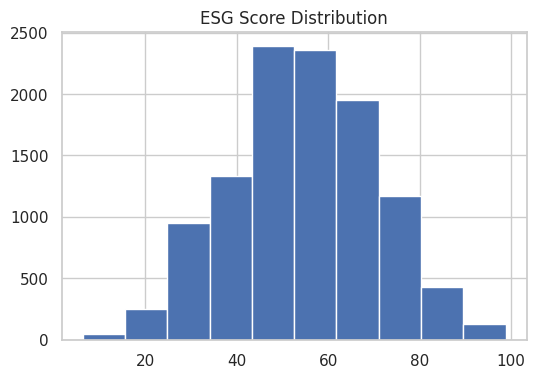

In [62]:
merged_df["ESG_Overall"].hist(figsize=(6,4))
plt.title("ESG Score Distribution")
plt.show()

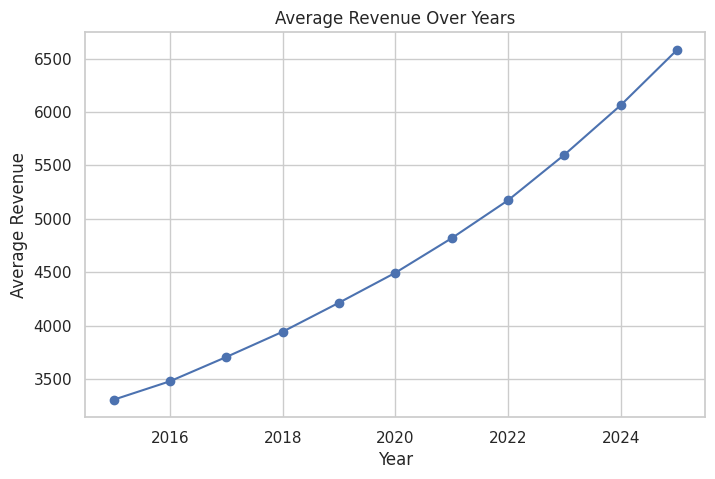

In [68]:
revenue_year = merged_df.groupby("Year")["Revenue"].mean()

plt.figure(figsize=(8,5))

plt.plot(
    revenue_year.index,
    revenue_year.values,
    marker="o"
)

plt.title("Average Revenue Over Years")
plt.xlabel("Year")
plt.ylabel("Average Revenue")

plt.grid(True)

plt.show()

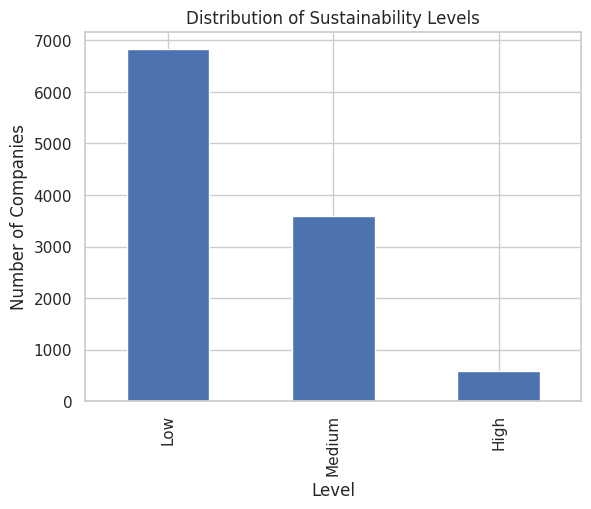

In [63]:
merged_df["Sustainability_Level"].value_counts().plot(kind="bar")
plt.title("Distribution of Sustainability Levels")
plt.xlabel("Level")
plt.ylabel("Number of Companies")
plt.show()

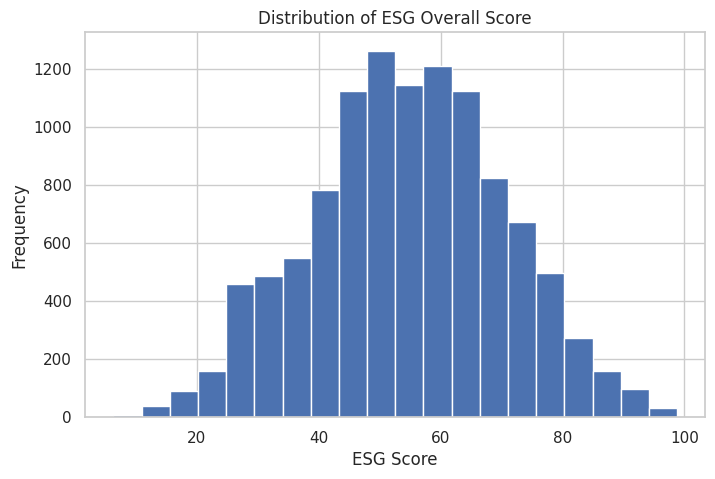

In [64]:
plt.figure(figsize=(8,5))
merged_df["ESG_Overall"].hist(bins=20)
plt.title("Distribution of ESG Overall Score")
plt.xlabel("ESG Score")
plt.ylabel("Frequency")
plt.show()

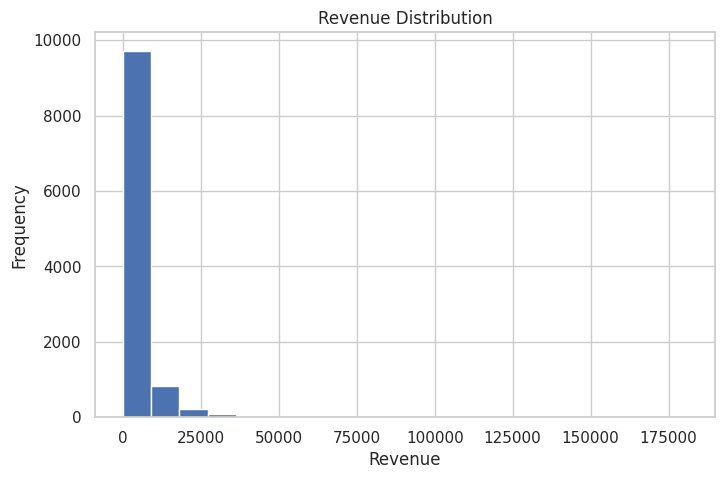

In [65]:
plt.figure(figsize=(8,5))
merged_df["Revenue"].hist(bins=20)
plt.title("Revenue Distribution")
plt.xlabel("Revenue")
plt.ylabel("Frequency")
plt.show()

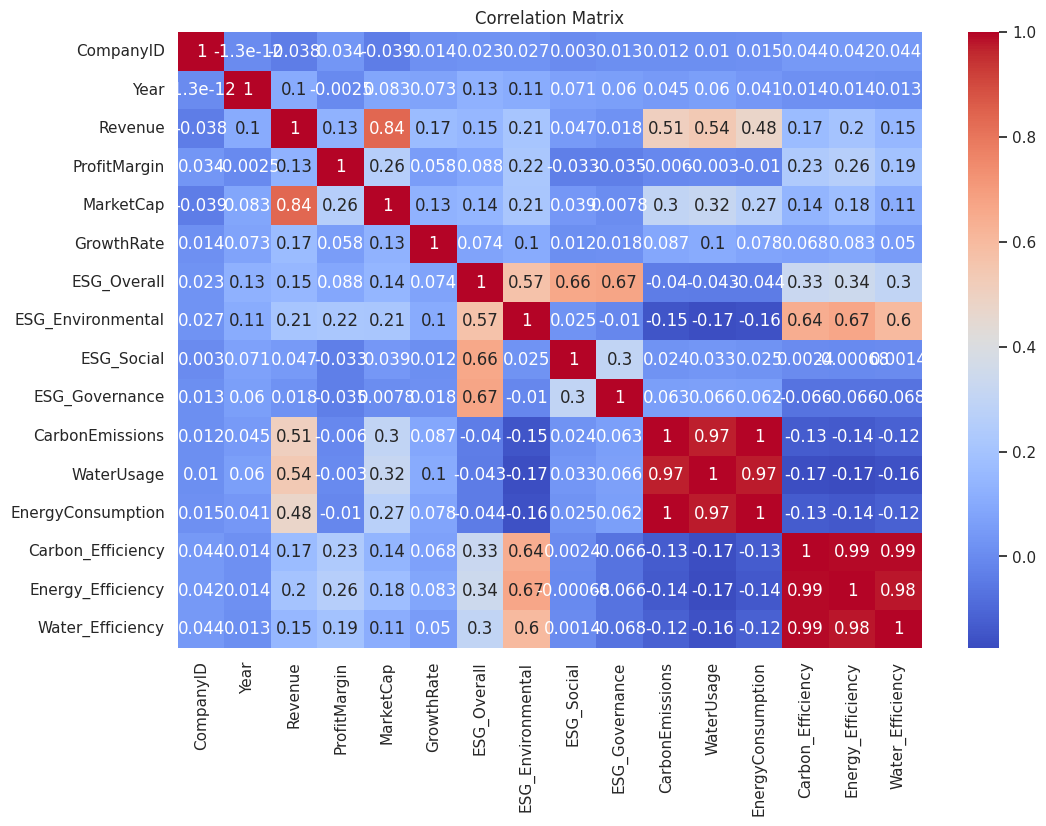

In [66]:
import seaborn as sns
plt.figure(figsize=(12,8))
sns.heatmap(
    merged_df.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm"
)
plt.title("Correlation Matrix")
plt.show()

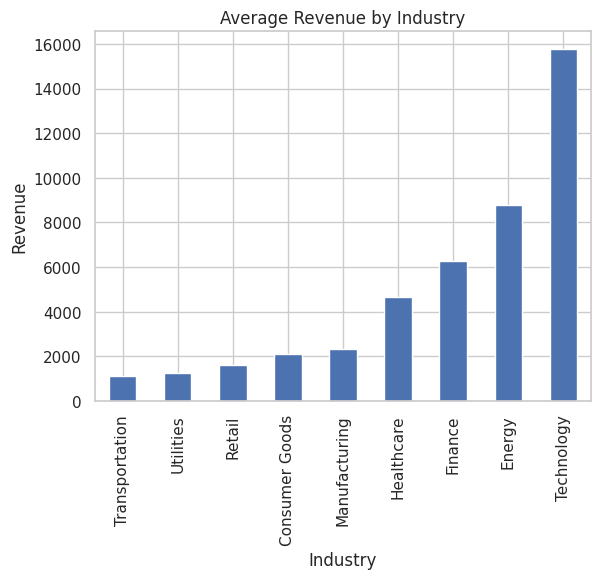

In [67]:
merged_df.groupby("Industry")["Revenue"].mean().sort_values().plot(kind="bar")
plt.title("Average Revenue by Industry")
plt.ylabel("Revenue")
plt.show()